# Experiment 4: Support Vector Machines

**Course:** 23CSE301 — Machine Learning Lab  
**Topic:** SVM for Binary Classification with Linear, RBF, Polynomial kernels  
**Dataset:** `diabetes.csv (Pima Indians Diabetes)`  
**Lab Book Reference:** §8 Support Vector Machines, page 31–37

---

## 🎯 Objective

Implement **Support Vector Machine** classifiers with **three different kernels** (linear, RBF, polynomial) on the Pima Indians Diabetes dataset. Compare accuracy, visualise the confusion matrix for the best kernel, and plot ROC curves. Feature scaling is **critical** for SVM, so we standardise all inputs first.

## ▶️ How to Run This Notebook

> **Option A — Google Colab (recommended if you don't have Python locally):**
> 1. Upload the entire `ML-Lab-Activities-Complete` folder to your Google Drive
>    (so it appears at `My Drive/ML-Lab-Activities-Complete/`).
> 2. In Colab, `File → Open notebook → Google Drive → 04-Support-Vector-Machines/04_*.ipynb`.
> 3. The first code cell auto-mounts Drive, chdir's to this experiment folder,
>    and creates an `outputs/` subfolder for every figure.
>
> **Option B — Local Jupyter:**
> ```bash
> # 1. (optional) create a virtual-env
> python -m venv .venv && source .venv/bin/activate
>
> # 2. install dependencies (one-time)
> pip install -r requirements.txt
>
> # 3. launch Jupyter from the repository root
> jupyter notebook 04-Support-Vector-Machines/04_*.ipynb
> ```
>
> **Option C — Headless execution:**
> ```bash
> jupyter nbconvert --to notebook --execute \
>   04-Support-Vector-Machines/04_*.ipynb \
>   --output executed.ipynb
> ```

Datasets are read from `../datasets/` (relative to the notebook's folder).
Generated figures are **auto-saved** to `./outputs/` inside this experiment's folder.


In [1]:
# === Environment setup (works in both Google Colab and local Jupyter) ===
import os, sys

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    # Adjust this path if you placed the folder elsewhere in your Drive
    BASE = '/content/drive/MyDrive/ML-Lab-Activities-Complete'
    os.chdir(os.path.join(BASE, '04-Support-Vector-Machines'))
    print(f'Running in Google Colab. Changed CWD to: {os.getcwd()}')
else:
    print(f'Running locally. CWD: {os.getcwd()}')

# Create outputs/ folder in this experiment's directory
OUTPUT_DIR = os.path.join(os.getcwd(), 'outputs')
os.makedirs(OUTPUT_DIR, exist_ok=True)

# --- Auto-save every matplotlib figure to outputs/ ---
# We patch plt.show() so that BEFORE a figure is shown, it is also saved
# to the outputs/ folder.  In the Jupyter inline backend, plt.show() is
# essentially a no-op (display happens automatically at cell-end), but it
# is still called inside every plotting cell — so this is the right hook.
import matplotlib.pyplot as plt

_fig_counter = [0]
_orig_plt_show = plt.show
def _save_and_show(*args, **kwargs):
    # Save every currently-open figure before showing
    for fnum in plt.get_fignums():
        _fig_counter[0] += 1
        fig = plt.figure(fnum)
        fname = f'figure_{_fig_counter[0]:03d}.png'
        try:
            fig.savefig(os.path.join(OUTPUT_DIR, fname), dpi=120, bbox_inches='tight')
        except Exception as e:
            print(f'Warning: could not save {fname}: {e}')
    _orig_plt_show(*args, **kwargs)
plt.show = _save_and_show

print('✅ Setup complete.')
print(f'   Datasets will be read from: {os.path.join(os.getcwd(), "..", "datasets")}')
print(f'   Figures will be auto-saved to: {OUTPUT_DIR}')


Running locally. CWD: /home/z/my-project/work/final/04-Support-Vector-Machines


✅ Setup complete.
   Datasets will be read from: /home/z/my-project/work/final/04-Support-Vector-Machines/../datasets
   Figures will be auto-saved to: /home/z/my-project/work/final/04-Support-Vector-Machines/outputs


## 1. Import Required Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn import metrics
from sklearn.metrics import (confusion_matrix, accuracy_score,
                             classification_report, roc_curve, auc,
                             precision_score, recall_score, f1_score)

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
import warnings; warnings.filterwarnings('ignore')
print("Libraries imported.")


Libraries imported.


## 2. Load Dataset

In [3]:
col_names = ['pregnant', 'glucose', 'bp', 'skin', 'insulin',
             'bmi', 'pedigree', 'age', 'label']

data = pd.read_csv('../datasets/diabetes.csv', header=None, names=col_names)

print(f"Shape: {data.shape}")
display(data.head())


Shape: (768, 9)


,pregnant,glucose,bp,skin,insulin,bmi,pedigree,age,label
0,6,129,71,15,202,38.8,0.119,55,1
1,14,113,70,29,3,17.3,0.330,29,0
2,10,144,75,11,27,40.1,0.142,55,0
3,7,53,84,17,18,41.7,0.080,31,1
4,6,127,81,20,21,29.9,0.491,64,1


## 3. Check Null Values & Define Features

In [4]:
print("Null values per column:")
print(data.isnull().sum())

feature_cols = ['pregnant', 'glucose', 'bp', 'skin', 'insulin',
               'bmi', 'pedigree', 'age']
X = data[feature_cols]
y = data['label']
print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")


Null values per column:
pregnant    0
glucose     0
bp          0
skin        0
insulin     0
bmi         0
pedigree    0
age         0
label       0
dtype: int64

X shape: (768, 8)
y shape: (768,)


## 4. Split Data (70/30)

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=5
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")


Train: (537, 8), Test: (231, 8)


## 5. Feature Scaling — CRITICAL for SVM

SVM maximises the margin in **distance-based** feature space, so features with large magnitudes
would dominate. We standardise all features to zero mean and unit variance.


In [6]:
sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled  = sc.transform(X_test)
print("Features standardised.")


Features standardised.


## 6. Train SVM with the **RBF** kernel

The Radial Basis Function (Gaussian) kernel is the default and usually the strongest kernel
for non-linear data.


In [7]:
svm_rbf = SVC(kernel='rbf', probability=True, random_state=5)
svm_rbf.fit(X_train_scaled, y_train)
y_pred_rbf = svm_rbf.predict(X_test_scaled)

cm_rbf = confusion_matrix(y_test, y_pred_rbf)
acc_rbf = accuracy_score(y_test, y_pred_rbf)
print("SVC [kernel = rbf]")
print("Confusion Matrix:")
print(cm_rbf)
print(f"Accuracy Score : {acc_rbf:.4f}")
print(f"Accuracy in %  : {int(acc_rbf*100)}%")
print(classification_report(y_test, y_pred_rbf,
      target_names=['No Diabetes', 'Diabetes']))


SVC [kernel = rbf]
Confusion Matrix:
[[149   1]
 [ 81   0]]
Accuracy Score : 0.6450
Accuracy in %  : 64%
              precision    recall  f1-score   support

 No Diabetes       0.65      0.99      0.78       150
    Diabetes       0.00      0.00      0.00        81

    accuracy                           0.65       231
   macro avg       0.32      0.50      0.39       231
weighted avg       0.42      0.65      0.51       231



## 7. Train SVM with the **Linear** kernel

In [8]:
svm_lin = SVC(kernel='linear', probability=True, random_state=5)
svm_lin.fit(X_train_scaled, y_train)
y_pred_lin = svm_lin.predict(X_test_scaled)

cm_lin = confusion_matrix(y_test, y_pred_lin)
acc_lin = accuracy_score(y_test, y_pred_lin)
print("SVC [kernel = linear]")
print("Confusion Matrix:")
print(cm_lin)
print(f"Accuracy Score : {acc_lin:.4f}")
print(f"Accuracy in %  : {int(acc_lin*100)}%")
print(classification_report(y_test, y_pred_lin,
      target_names=['No Diabetes', 'Diabetes']))


SVC [kernel = linear]
Confusion Matrix:
[[150   0]
 [ 81   0]]
Accuracy Score : 0.6494
Accuracy in %  : 64%
              precision    recall  f1-score   support

 No Diabetes       0.65      1.00      0.79       150
    Diabetes       0.00      0.00      0.00        81

    accuracy                           0.65       231
   macro avg       0.32      0.50      0.39       231
weighted avg       0.42      0.65      0.51       231



## 8. Train SVM with the **Polynomial** kernel (degree=3)

In [9]:
svm_poly = SVC(kernel='poly', degree=3, probability=True, random_state=5)
svm_poly.fit(X_train_scaled, y_train)
y_pred_poly = svm_poly.predict(X_test_scaled)

cm_poly = confusion_matrix(y_test, y_pred_poly)
acc_poly = accuracy_score(y_test, y_pred_poly)
print("SVC [kernel = poly, degree=3]")
print("Confusion Matrix:")
print(cm_poly)
print(f"Accuracy Score : {acc_poly:.4f}")
print(f"Accuracy in %  : {int(acc_poly*100)}%")


SVC [kernel = poly, degree=3]
Confusion Matrix:
[[136  14]
 [ 79   2]]
Accuracy Score : 0.5974
Accuracy in %  : 59%


## 9. Compare All Kernels

In [10]:
results = pd.DataFrame({
    'Kernel'    : ['Linear', 'RBF', 'Polynomial'],
    'Accuracy'  : [acc_lin, acc_rbf, acc_poly],
    'Precision' : [precision_score(y_test, y_pred_lin),
                   precision_score(y_test, y_pred_rbf),
                   precision_score(y_test, y_pred_poly)],
    'Recall'    : [recall_score(y_test, y_pred_lin),
                   recall_score(y_test, y_pred_rbf),
                   recall_score(y_test, y_pred_poly)],
    'F1'        : [f1_score(y_test, y_pred_lin),
                   f1_score(y_test, y_pred_rbf),
                   f1_score(y_test, y_pred_poly)],
}).round(4)
print(results.to_string(index=False))

best_kernel = results.loc[results['Accuracy'].idxmax(), 'Kernel']
print(f"\n🏆 Best kernel: {best_kernel}")


    Kernel  Accuracy  Precision  Recall     F1
    Linear    0.6494      0.000  0.0000 0.0000
       RBF    0.6450      0.000  0.0000 0.0000
Polynomial    0.5974      0.125  0.0247 0.0412

🏆 Best kernel: Linear


## 10. Visualise Confusion Matrix (RBF kernel)

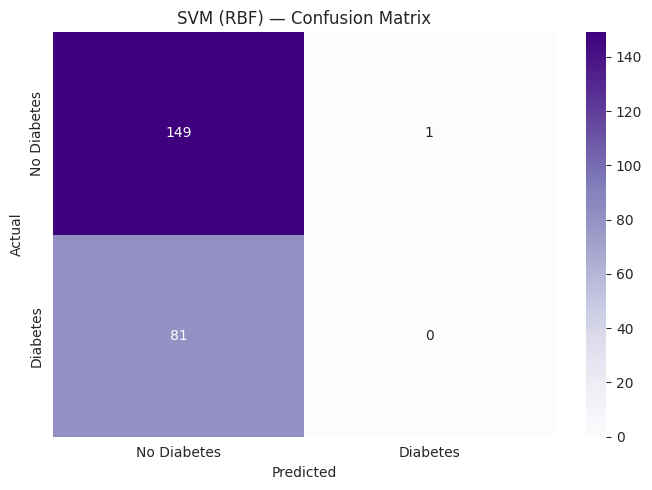

In [11]:
plt.figure(figsize=(7, 5))
sns.heatmap(cm_rbf, annot=True, fmt='d', cmap='Purples',
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('SVM (RBF) — Confusion Matrix')
plt.tight_layout()
plt.show()


## 11. ROC Curve for All Kernels

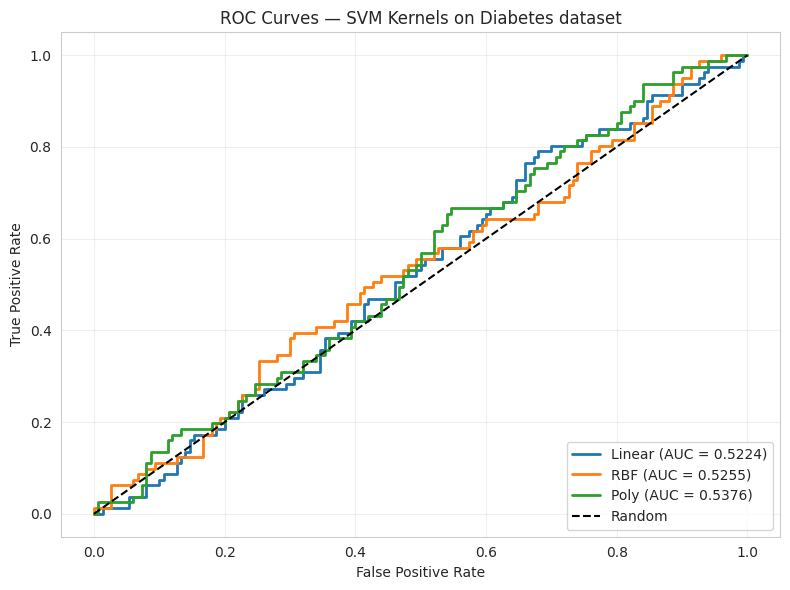

In [12]:
plt.figure(figsize=(8, 6))
for name, est, y_p in [('Linear', svm_lin, y_pred_lin),
                       ('RBF'   , svm_rbf, y_pred_rbf),
                       ('Poly'  , svm_poly, y_pred_poly)]:
    proba = est.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC = {auc(fpr, tpr):.4f})")
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — SVM Kernels on Diabetes dataset')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 12. Hyper-parameter tuning: effect of `C`

`C` is the regularisation parameter — small C = stronger regularisation (wider margin, more
margin violations); large C = weaker regularisation (tries to classify every training point
correctly, may overfit).


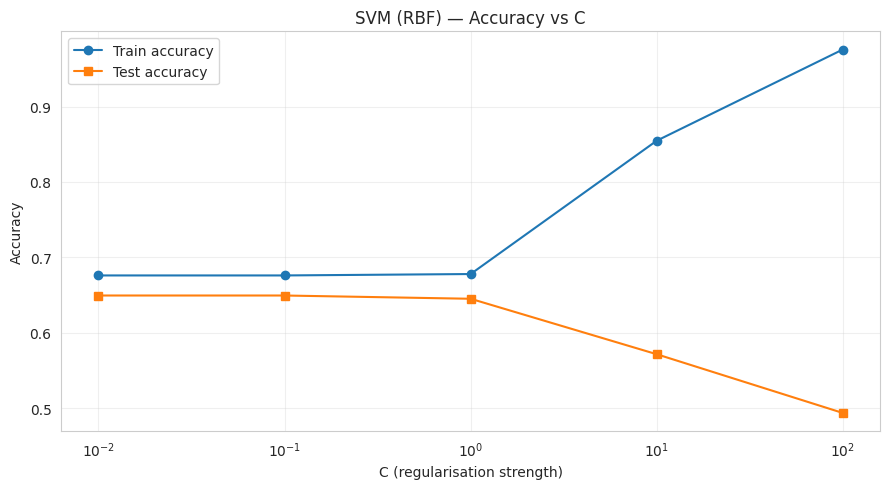

In [13]:
C_values = [0.01, 0.1, 1, 10, 100]
train_acc, test_acc = [], []
for c in C_values:
    svm = SVC(kernel='rbf', C=c, random_state=5)
    svm.fit(X_train_scaled, y_train)
    train_acc.append(svm.score(X_train_scaled, y_train))
    test_acc.append(svm.score(X_test_scaled,  y_test))

plt.figure(figsize=(9, 5))
plt.semilogx(C_values, train_acc, 'o-', label='Train accuracy')
plt.semilogx(C_values, test_acc,  's-', label='Test accuracy')
plt.xlabel('C (regularisation strength)')
plt.ylabel('Accuracy')
plt.title('SVM (RBF) — Accuracy vs C')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 📝 Exercises

> Submit the Colab link or GitHub link or any `.ipynb` file for the exercises.

1. Generate a random dataset that follows a **quadratic distribution** and classify it with an SVM using a polynomial kernel.
2. Classify **emails as spam or not spam** based on features such as word frequency and message length using an SVM with an RBF kernel.
3. Apply **GridSearchCV** to find the best `(C, gamma)` for the RBF kernel on the diabetes dataset.


---

## 📚 Key Takeaways

- **SVM** finds the hyperplane that maximises the margin between classes.
- **Support vectors** are the data points closest to the hyperplane — they define it.
- **Kernels** (linear, RBF, polynomial) let SVM model non-linear decision boundaries via the *kernel trick*.
- **Feature scaling is mandatory** for SVM — unscaled features distort the margin.
- **Trade-offs:** SVM is computationally expensive on large datasets; choosing the kernel and `C` requires tuning.

## 🔗 References

- Lab Activity Book (23CSE301), Department of CSE.
- Scikit-learn User Guide: <https://scikit-learn.org/stable/user_guide.html>
